# Taxpayer Risk Classification using Random Forest

## Objective
This project classifies taxpayers into **Good** and **Risky** categories based on taxable income and demographic attributes.  
The goal is to support **risk-based review prioritization**, where analysts can identify taxpayer profiles that may need closer review.

## Problem Statement
Tax authorities or financial-risk teams often need to prioritize limited review resources. This project uses machine learning to classify taxpayers into:

- **Good**: Taxable income above 30,000
- **Risky**: Taxable income less than or equal to 30,000

The analysis compares two Random Forest approaches:

1. **Baseline Random Forest with stratified train-test split**
2. **Random Forest with SMOTE applied only on training data**

This helps compare the trade-off between overall accuracy and minority-class detection.

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)

## Load Dataset

In [2]:
# Load the dataset
DATA_PATH = 'Fraud_check.csv'
df = pd.read_csv(DATA_PATH)

# Display first few rows
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [3]:
# Dataset shape and information
print('Dataset shape:', df.shape)
df.info()

Dataset shape: (600, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.3+ KB


In [4]:
# Check missing values
missing_values = df.isnull().sum()
missing_values

Undergrad          0
Marital.Status     0
Taxable.Income     0
City.Population    0
Work.Experience    0
Urban              0
dtype: int64

## Target Variable Creation

The dataset does not contain a direct fraud label. A risk category is created using taxable income:

- `Risky` if `Taxable.Income <= 30000`
- `Good` if `Taxable.Income > 30000`

`Taxable.Income` is then removed from model inputs to avoid data leakage, because it is used to create the target variable.

In [5]:
# Create target variable
threshold = 30000
df['Risk_Category'] = np.where(df['Taxable.Income'] <= threshold, 'Risky', 'Good')

# Check class distribution
class_counts = df['Risk_Category'].value_counts()
class_percent = df['Risk_Category'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percent.round(2)
})

,Count,Percentage
Risk_Category,,
Good,476,79.33
Risky,124,20.67


# Exploratory Data Analysis

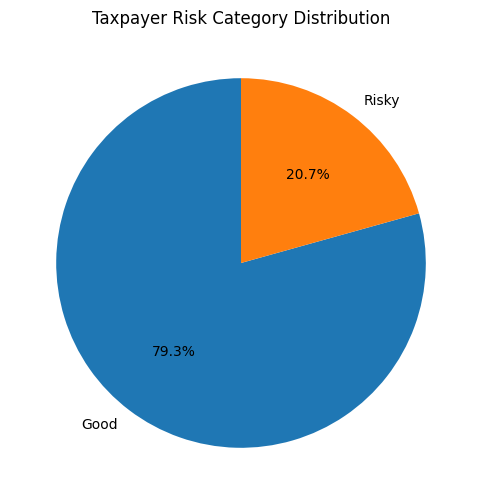

In [6]:
# Pie chart for target distribution
plt.figure(figsize=(6, 6))
df['Risk_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ylabel=''
)
plt.title('Taxpayer Risk Category Distribution')
plt.show()

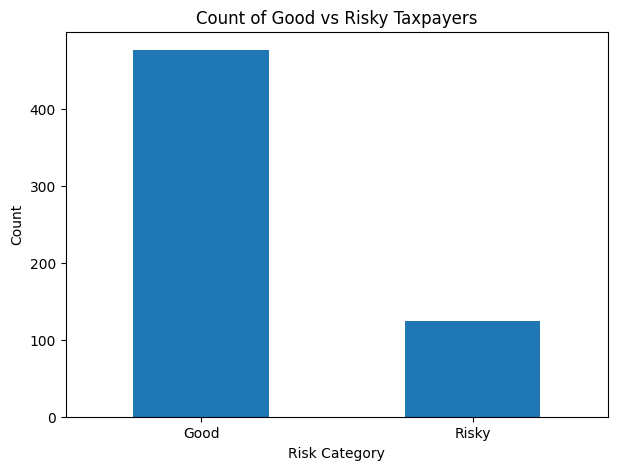

In [7]:
# Bar chart for target distribution
plt.figure(figsize=(7, 5))
df['Risk_Category'].value_counts().plot(kind='bar')
plt.title('Count of Good vs Risky Taxpayers')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

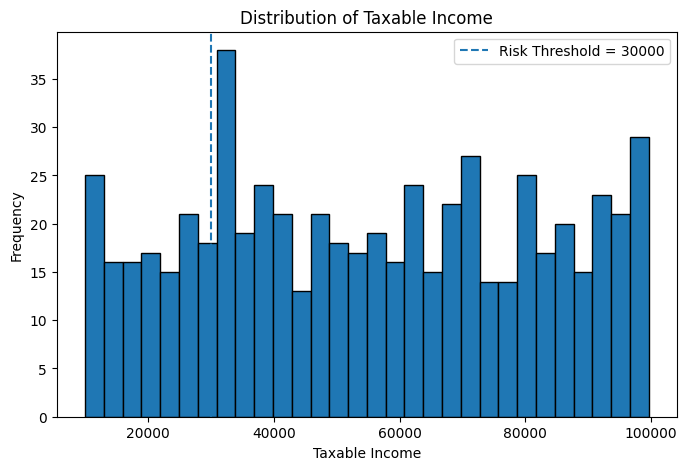

In [8]:
# Taxable income distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Taxable.Income'], bins=30, edgecolor='black')
plt.axvline(threshold, linestyle='--', label='Risk Threshold = 30000')
plt.title('Distribution of Taxable Income')
plt.xlabel('Taxable Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

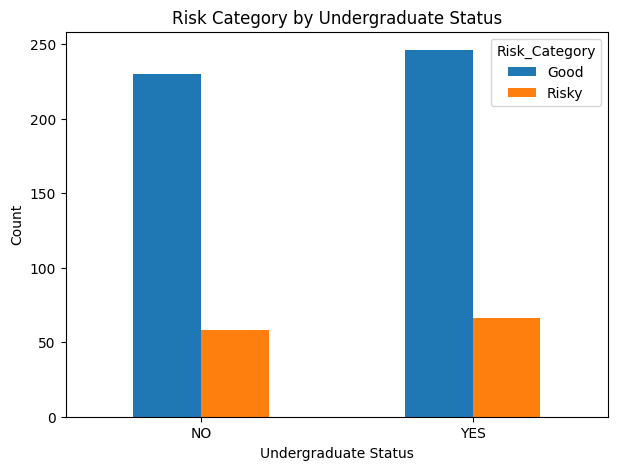

In [9]:
# Risk category by undergraduate status
pd.crosstab(df['Undergrad'], df['Risk_Category']).plot(kind='bar', figsize=(7, 5))
plt.title('Risk Category by Undergraduate Status')
plt.xlabel('Undergraduate Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

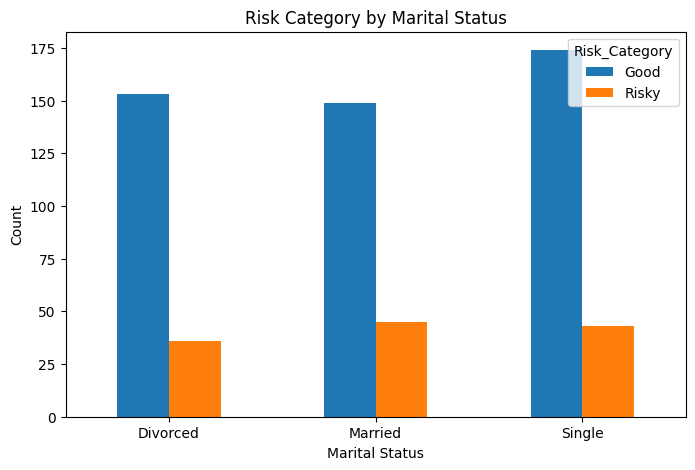

In [10]:
# Risk category by marital status
pd.crosstab(df['Marital.Status'], df['Risk_Category']).plot(kind='bar', figsize=(8, 5))
plt.title('Risk Category by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

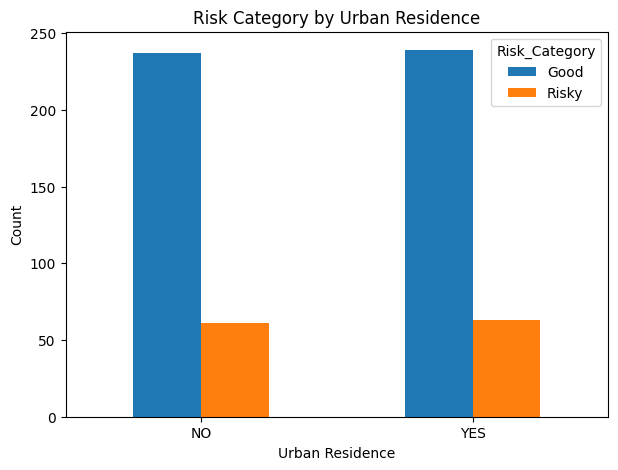

In [11]:
# Risk category by urban/rural status
pd.crosstab(df['Urban'], df['Risk_Category']).plot(kind='bar', figsize=(7, 5))
plt.title('Risk Category by Urban Residence')
plt.xlabel('Urban Residence')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<Figure size 700x500 with 0 Axes>

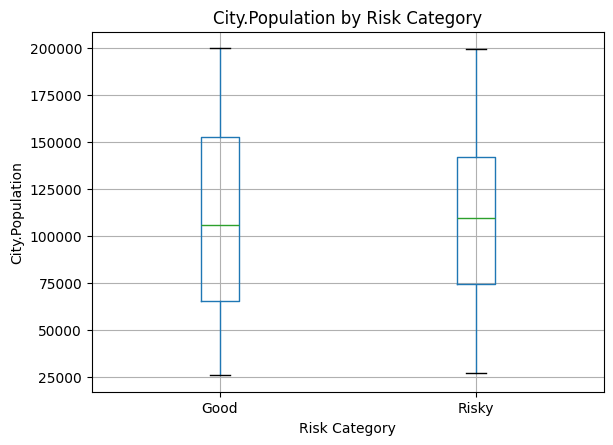

<Figure size 700x500 with 0 Axes>

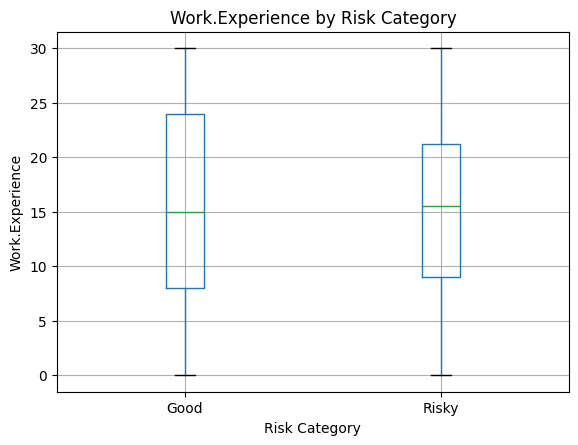

<Figure size 700x500 with 0 Axes>

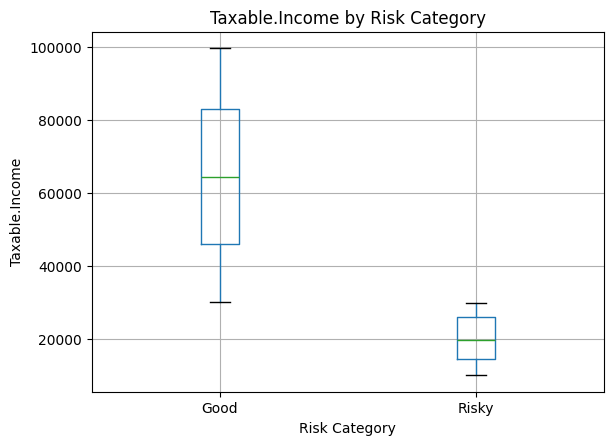

In [12]:
# Boxplots for numerical variables by risk category
numeric_cols = ['City.Population', 'Work.Experience', 'Taxable.Income']

for col in numeric_cols:
    plt.figure(figsize=(7, 5))
    df.boxplot(column=col, by='Risk_Category')
    plt.title(f'{col} by Risk Category')
    plt.suptitle('')
    plt.xlabel('Risk Category')
    plt.ylabel(col)
    plt.show()

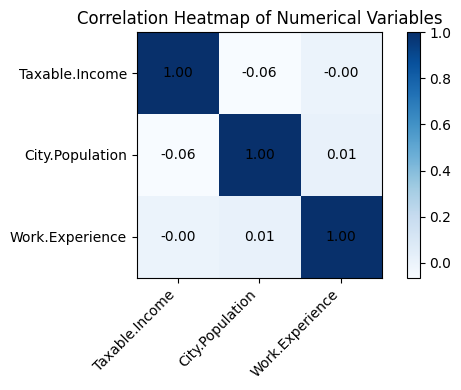

In [13]:
# Correlation heatmap for numerical columns
corr = df[['Taxable.Income', 'City.Population', 'Work.Experience']].corr()
plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## Data Preparation

Important steps:

- `Taxable.Income` is not used as an input feature because it defines the target variable.
- Categorical columns are encoded using OneHotEncoder.
- Train-test split uses `stratify=y` so both train and test sets keep similar Good/Risky proportions.
- SMOTE is applied only to the training data in the second model.

In [14]:
# Define features and target
X = df.drop(columns=['Taxable.Income', 'Risk_Category'])
y = df['Risk_Category']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical columns:', categorical_cols)
print('Numerical columns:', numerical_cols)

Categorical columns: ['Undergrad', 'Marital.Status', 'Urban']
Numerical columns: ['City.Population', 'Work.Experience']


In [15]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Original target distribution:')
print(y.value_counts(normalize=True).round(3))

print('\nTraining target distribution:')
print(y_train.value_counts(normalize=True).round(3))

print('\nTesting target distribution:')
print(y_test.value_counts(normalize=True).round(3))

Original target distribution:
Risk_Category
Good     0.793
Risky    0.207
Name: proportion, dtype: float64

Training target distribution:
Risk_Category
Good     0.794
Risky    0.206
Name: proportion, dtype: float64

Testing target distribution:
Risk_Category
Good     0.792
Risky    0.208
Name: proportion, dtype: float64


In [16]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

# Model 1: Baseline Random Forest with Stratified Split

In [17]:
# Baseline Random Forest model
baseline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight=None
    ))
])

baseline_rf.fit(X_train, y_train)
y_pred_base = baseline_rf.predict(X_test)
y_proba_base = baseline_rf.predict_proba(X_test)[:, list(baseline_rf.classes_).index('Risky')]

In [18]:
# Baseline model evaluation
print('Baseline Random Forest Evaluation')
print('-' * 40)
print('Accuracy:', round(accuracy_score(y_test, y_pred_base), 4))
print('Macro F1-score:', round(f1_score(y_test, y_pred_base, average='macro'), 4))
print('Risky Recall:', round(recall_score(y_test, y_pred_base, pos_label='Risky'), 4))
print('Risky Precision:', round(precision_score(y_test, y_pred_base, pos_label='Risky', zero_division=0), 4))
print('ROC-AUC:', round(roc_auc_score((y_test == 'Risky').astype(int), y_proba_base), 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, zero_division=0))

Baseline Random Forest Evaluation
----------------------------------------
Accuracy: 0.7333
Macro F1-score: 0.4231
Risky Recall: 0.0
Risky Precision: 0.0
ROC-AUC: 0.3451

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.93      0.85        95
       Risky       0.00      0.00      0.00        25

    accuracy                           0.73       120
   macro avg       0.39      0.46      0.42       120
weighted avg       0.62      0.73      0.67       120



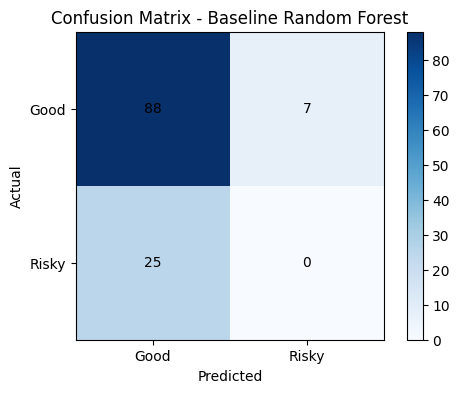

In [19]:
# Confusion matrix - baseline model
cm_base = confusion_matrix(y_test, y_pred_base, labels=['Good', 'Risky'])

plt.figure(figsize=(6, 4))
plt.imshow(cm_base, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Good', 'Risky'])
plt.yticks([0, 1], ['Good', 'Risky'])
for i in range(cm_base.shape[0]):
    for j in range(cm_base.shape[1]):
        plt.text(j, i, cm_base[i, j], ha='center', va='center')
plt.title('Confusion Matrix - Baseline Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model 2: Random Forest with SMOTE

SMOTE is used to create synthetic samples for the minority class in the training data.  
This is useful when the business objective is to improve detection of minority cases such as risky taxpayers.

Note: SMOTE is applied **only on training data**, never on the test data.

In [20]:
# Random Forest with SMOTE
smote_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=42
    ))
])

smote_rf.fit(X_train, y_train)
y_pred_smote = smote_rf.predict(X_test)
y_proba_smote = smote_rf.predict_proba(X_test)[:, list(smote_rf.classes_).index('Risky')]

In [21]:
# Visualize class distribution before and after SMOTE on training data
X_train_encoded = preprocessor.fit_transform(X_train)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

before_after = pd.DataFrame({
    'Before SMOTE': y_train.value_counts(),
    'After SMOTE': pd.Series(y_train_smote).value_counts()
}).fillna(0).astype(int)

before_after

,Before SMOTE,After SMOTE
Risk_Category,,
Good,381,381
Risky,99,381


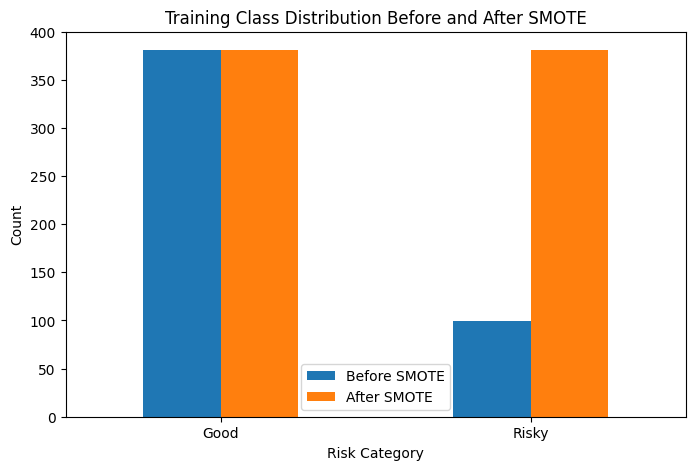

In [22]:
# Bar chart: before and after SMOTE
before_after.plot(kind='bar', figsize=(8, 5))
plt.title('Training Class Distribution Before and After SMOTE')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [23]:
# SMOTE model evaluation
print('Random Forest with SMOTE Evaluation')
print('-' * 40)
print('Accuracy:', round(accuracy_score(y_test, y_pred_smote), 4))
print('Macro F1-score:', round(f1_score(y_test, y_pred_smote, average='macro'), 4))
print('Risky Recall:', round(recall_score(y_test, y_pred_smote, pos_label='Risky'), 4))
print('Risky Precision:', round(precision_score(y_test, y_pred_smote, pos_label='Risky', zero_division=0), 4))
print('ROC-AUC:', round(roc_auc_score((y_test == 'Risky').astype(int), y_proba_smote), 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_smote, zero_division=0))

Random Forest with SMOTE Evaluation
----------------------------------------
Accuracy: 0.675
Macro F1-score: 0.403
Risky Recall: 0.0
Risky Precision: 0.0
ROC-AUC: 0.3333

Classification Report:
              precision    recall  f1-score   support

        Good       0.76      0.85      0.81        95
       Risky       0.00      0.00      0.00        25

    accuracy                           0.68       120
   macro avg       0.38      0.43      0.40       120
weighted avg       0.60      0.68      0.64       120



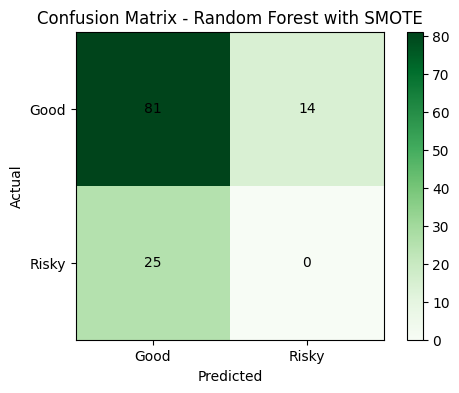

In [24]:
# Confusion matrix - SMOTE model
cm_smote = confusion_matrix(y_test, y_pred_smote, labels=['Good', 'Risky'])

plt.figure(figsize=(6, 4))
plt.imshow(cm_smote, cmap='Greens')
plt.colorbar()
plt.xticks([0, 1], ['Good', 'Risky'])
plt.yticks([0, 1], ['Good', 'Risky'])
for i in range(cm_smote.shape[0]):
    for j in range(cm_smote.shape[1]):
        plt.text(j, i, cm_smote[i, j], ha='center', va='center')
plt.title('Confusion Matrix - Random Forest with SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Comparison

In [25]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Random Forest + SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_smote)
    ],
    'Macro F1-score': [
        f1_score(y_test, y_pred_base, average='macro'),
        f1_score(y_test, y_pred_smote, average='macro')
    ],
    'Risky Recall': [
        recall_score(y_test, y_pred_base, pos_label='Risky'),
        recall_score(y_test, y_pred_smote, pos_label='Risky')
    ],
    'Risky Precision': [
        precision_score(y_test, y_pred_base, pos_label='Risky', zero_division=0),
        precision_score(y_test, y_pred_smote, pos_label='Risky', zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score((y_test == 'Risky').astype(int), y_proba_base),
        roc_auc_score((y_test == 'Risky').astype(int), y_proba_smote)
    ]
})

comparison.round(4)

,Model,Accuracy,Macro F1-score,Risky Recall,Risky Precision,ROC-AUC
0,Baseline Random Forest,0.7333,0.4231,0.0,0.0,0.3451
1,Random Forest + SMOTE,0.6750,0.4030,0.0,0.0,0.3333


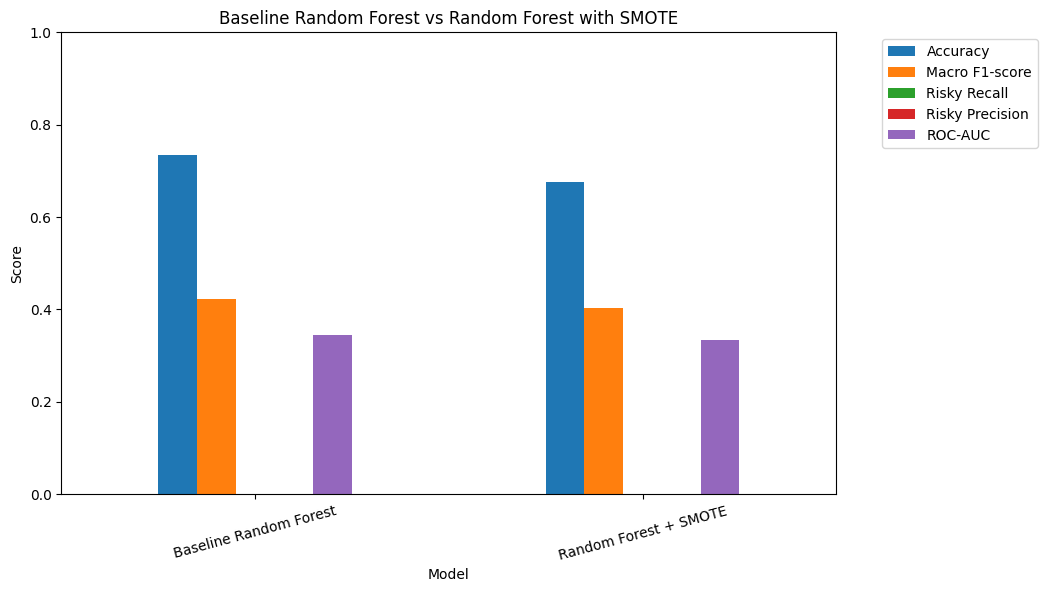

In [26]:
# Model comparison chart
comparison.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Baseline Random Forest vs Random Forest with SMOTE')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [27]:
# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv = cross_val_score(baseline_rf, X, y, cv=cv, scoring='f1_macro')
smote_cv = cross_val_score(smote_rf, X, y, cv=cv, scoring='f1_macro')

cv_results = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Random Forest + SMOTE'],
    'Mean CV Macro F1': [baseline_cv.mean(), smote_cv.mean()],
    'Std CV Macro F1': [baseline_cv.std(), smote_cv.std()]
})

cv_results.round(4)

,Model,Mean CV Macro F1,Std CV Macro F1
0,Baseline Random Forest,0.4637,0.0330
1,Random Forest + SMOTE,0.4721,0.0321


# Feature Importance

Feature importance helps business users understand which factors influence risk classification the most.

In [28]:
# Feature importance from SMOTE model
feature_names = smote_rf.named_steps['preprocessor'].get_feature_names_out()
importances = smote_rf.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
7,num__City.Population,0.292963
8,num__Work.Experience,0.215102
4,cat__Marital.Status_Single,0.089524
2,cat__Marital.Status_Divorced,0.082765
0,cat__Undergrad_NO,0.080104
1,cat__Undergrad_YES,0.075425
3,cat__Marital.Status_Married,0.068873
5,cat__Urban_NO,0.048444
6,cat__Urban_YES,0.046800


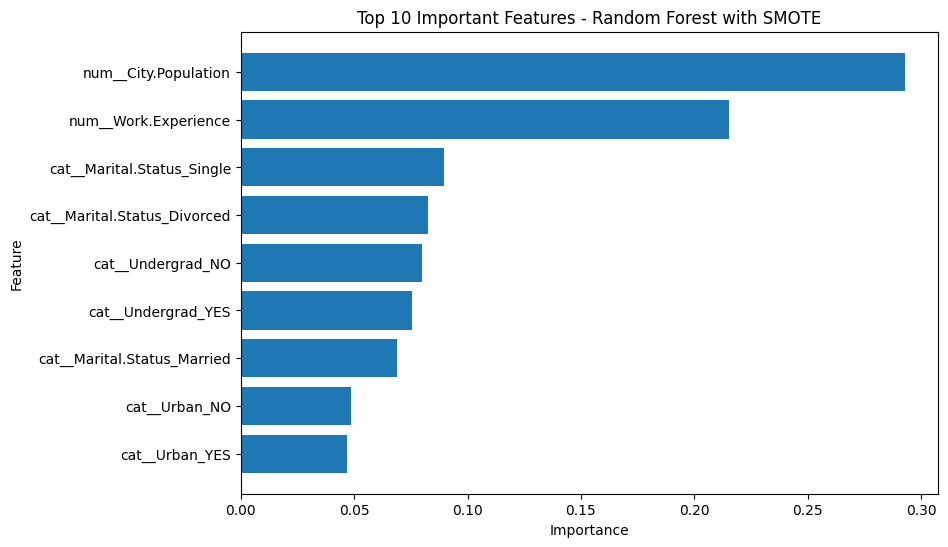

In [29]:
# Plot top feature importances
top_features = feature_importance.head(10).sort_values('Importance')
plt.figure(figsize=(9, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Important Features - Random Forest with SMOTE')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Key Observations

- The dataset is moderately imbalanced, with more **Good** taxpayers than **Risky** taxpayers.
- Stratified train-test split keeps the same class proportion in both training and testing data, making evaluation more reliable.
- SMOTE balances only the training data by generating synthetic minority-class samples.
- The test data is kept original and untouched, which gives a more honest model evaluation.
- In this dataset, the available features have limited power to identify the Risky class. This means high accuracy can be misleading if the model mostly predicts the majority class.
- For a business risk project, **Risky recall**, **Macro F1-score**, and **confusion matrix** are more important than accuracy alone.

# Conclusion

This project compares two Random Forest approaches for taxpayer risk classification. The baseline model uses stratified sampling to preserve class distribution, while the second model applies SMOTE to improve minority-class learning.

The goal is not only to maximize accuracy but also to correctly identify potentially risky taxpayers. SMOTE is useful when the business wants better minority-class detection, but it may also increase false positives or reduce overall accuracy.

The final model should be selected based on the business priority:

- Use the **baseline model** if overall stability and fewer false alarms are more important.
- Use the **SMOTE model** if identifying more Risky taxpayers is more important for review prioritization.

Overall, the project demonstrates how class imbalance handling, model evaluation, and business interpretation are connected in real-world risk analytics.